<a href="https://colab.research.google.com/github/ma5029blp-wq/pricesense/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/PakWheels Dataset.csv")

print(df.shape)
df.info()
display(df.head())

(61919, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61919 entries, 0 to 61918
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   nam              61919 non-null  object
 1   Price            61919 non-null  object
 2   Year             61919 non-null  int64 
 3   Millage          61919 non-null  object
 4   Fuel             61919 non-null  object
 5   Transmission     61919 non-null  object
 6   Province         61919 non-null  object
 7   Color            61918 non-null  object
 8   Assembly         61919 non-null  object
 9   Engine Capacity  61919 non-null  object
 10  Body Type        54732 non-null  object
 11  Ad Reference     61919 non-null  int64 
 12  Features         58042 non-null  object
 13  Owner nam        53493 non-null  object
 14  url              61919 non-null  object
dtypes: int64(2), object(13)
memory usage: 7.1+ MB


,nam,Price,Year,Millage,Fuel,Transmission,Province,Color,Assembly,Engine Capacity,Body Type,Ad Reference,Features,Owner nam,url
0,Suzuki Alto VXL AGS 2022,PKR 23.9 lacs,2022,"120,000 km",Petrol,Automatic,Islamabad,Solid White,Local,660 cc,Hatchback,10313920,"['ABS', 'AM/FM Radio', 'Air Bags', 'Air Condit...",Daniyal,https://www.pakwheels.com//used-cars/suzuki-al...
1,Honda N Box Custom GL 2022,PKR 33.4 lacs,2022,"37,110 km",Petrol,Automatic,Islamabad,White,Imported,658 cc,Hatchback,10233745,"['ABS', 'AM/FM Radio', 'Air Bags', 'Air Condit...",NaN,https://www.pakwheels.com//used-cars/honda-n-b...
2,Honda Civic EX 1995,PKR 6.3 lacs,1995,786 km,LPG,Manual,Karachi,Black,Local,1500 cc,Sedan,10313884,"['AM/FM Radio', 'Air Conditioning', 'Cassette ...",Abdullah Sheikh,https://www.pakwheels.com//used-cars/honda-civ...
3,Toyota Corolla GLi Automatic 1.6 VVTi 2012,PKR 33.25 lacs,2012,"133,000 km",Petrol,Automatic,Lahore,Medium Silver,Imported,1600 cc,Sedan,10311918,"['ABS', 'AM/FM Radio', 'Air Conditioning', 'CD...",Zakiulhassan,https://www.pakwheels.com//used-cars/toyota-co...
4,Toyota Corolla Hatchback 1998,PKR 16.45 lacs,1998,"125,225 km",Petrol,Automatic,Punjab,Black,Local,1600 cc,NaN,10207521,"['ABS', 'AM/FM Radio', 'Air Bags', 'Air Condit...",NaN,https://www.pakwheels.com//used-cars/toyota-co...


In [16]:
display(df.describe())
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print(df.select_dtypes("object").nunique())

,Year,Ad Reference
count,61919.000000,6.191900e+04
mean,2012.798026,1.021495e+07
std,9.000544,2.196495e+05
min,1900.000000,1.955064e+06
25%,2007.000000,1.021720e+07
50%,2015.000000,1.025864e+07
75%,2020.000000,1.029217e+07
max,2025.000000,1.031861e+07


nam                   0
Price                 0
Year                  0
Millage               0
Fuel                  0
Transmission          0
Province              0
Color                 1
Assembly              0
Engine Capacity       0
Body Type          7187
Ad Reference          0
Features           3877
Owner nam          8426
url                   0
dtype: int64
Duplicates: 0
nam                 8809
Price               2204
Millage             9011
Fuel                   6
Transmission           2
Province             123
Color                983
Assembly               2
Engine Capacity      251
Body Type             21
Features            5077
Owner nam          27326
url                61911
dtype: int64


In [17]:
# Which price units exist?
print(df["Price"].str.extract(r"(lacs|crore|PKR)\s*$")[0].value_counts(dropna=False))
print(df["Price"].sample(10, random_state=2).tolist())

# Which mileage / engine formats exist?
print(df["Millage"].sample(10, random_state=2).tolist())
print(df["Engine Capacity"].sample(10, random_state=2).tolist())

# Duplicates
print("Full duplicate rows:", df.duplicated().sum())
print("Duplicate Ad References:", df["Ad Reference"].duplicated().sum())

# Location values
print(df["Province"].value_counts().head(15))

0
lacs     57713
crore     3353
NaN        853
Name: count, dtype: int64
['PKR 31.25 lacs', 'PKR 51.5 lacs', 'PKR 15 lacs', 'PKR 7.5 lacs', 'PKR 30.5 lacs', 'PKR 45.99 lacs', 'PKR 14.5 lacs', 'PKR 41.5 lacs', 'PKR 40 lacs', 'PKR 1.27 crore']
['18,200 km', '125,000 km', '69,000 km', '95,333 km', '230,000 km', '85,000 km', '108,000 km', '120,000 km', '92,000 km', '15 km']
['1500 cc', '1800 cc', '796 cc', '1000 cc', '1300 cc', '1000 cc', '660 cc', '1600 cc', '1300 cc', '1600 cc']
Full duplicate rows: 0
Duplicate Ad References: 8
Province
Islamabad          13453
Lahore             12869
Punjab              9258
Sindh               8449
Karachi             7953
Un-Registered       5687
Rawalpindi           786
Multan               607
Peshawar             535
Faisalabad           518
Abbottabad           300
Adda jahan khan      214
Sialkot              191
Gujranwala           124
Bahawalpur            96
Name: count, dtype: int64


In [18]:
# 1) The 853 prices with no lacs/crore unit
no_unit = df["Price"].str.extract(r"(lacs|crore)\s*$")[0].isna()
print(df.loc[no_unit, "Price"].value_counts().head(15))
print(df.loc[no_unit, "Price"].sample(10, random_state=1).tolist())

# 2) Mileage as a number, to see how extreme it gets
km = pd.to_numeric(df["Millage"].str.replace(r"[^\d]", "", regex=True), errors="coerce")
print(km.describe())
print("Mileage < 1000 km:", (km < 1000).sum())
print("Mileage > 500,000 km:", (km > 500_000).sum())

# 3) Engine capacity blanks, bad years, categories
cc = pd.to_numeric(df["Engine Capacity"].str.replace(r"[^\d]", "", regex=True), errors="coerce")
print("Engine not numeric:", cc.isna().sum())
print("Year < 1970:", (df["Year"] < 1970).sum())
print(df["Fuel"].value_counts())
print(df["Body Type"].value_counts())

Price
Call for price    853
Name: count, dtype: int64
['Call for price', 'Call for price', 'Call for price', 'Call for price', 'Call for price', 'Call for price', 'Call for price', 'Call for price', 'Call for price', 'Call for price']
count      61919.000000
mean       99841.268044
std        92636.581567
min            1.000000
25%        44000.000000
50%        87254.000000
75%       131000.000000
max      1000000.000000
Name: Millage, dtype: float64
Mileage < 1000 km: 2562
Mileage > 500,000 km: 405
Engine not numeric: 0
Year < 1970: 34
Fuel
Petrol      53431
Hybrid       4875
Diesel       2258
CNG           651
Electric      550
LPG           154
Name: count, dtype: int64
Body Type
Hatchback            22785
Sedan                19521
SUV                   3716
Crossover             3640
Mini Van              1053
Van                    579
Micro Van              526
Double Cabin           476
Pick Up                467
Compact sedan          447
MPV                    431
Compact S

In [24]:
%%writefile src/cleaning.py
"""Cleaning functions for the PriceSense PakWheels dataset."""
import re
import ast
import numpy as np
import pandas as pd

CURRENT_YEAR = 2025
TWO_WORD_MAKES = ["Land Rover", "Range Rover", "Mercedes Benz", "Alfa Romeo",
                  "Rolls Royce", "Aston Martin", "Great Wall"]
# first word + second word that together form ONE model name
MODEL_PAIRS = {("land", "cruiser"), ("wagon", "r"), ("n", "box"), ("n", "wgn"),
               ("n", "one"), ("n", "van")}
JOIN_NEXT = {"class", "series"}      # "C Class", "7 Series"


def parse_price(text):
    """'PKR 1.27 crore' -> 12,700,000.  'Call for price' -> NaN."""
    m = re.search(r"([\d.,]+)\s*(lacs|crore)", str(text))
    if not m:
        return np.nan
    value = float(m.group(1).replace(",", ""))
    return value * (100_000 if m.group(2) == "lacs" else 10_000_000)


def to_number(series):
    """'120,000 km' -> 120000.  Anything unparseable -> NaN."""
    return pd.to_numeric(series.astype(str).str.replace(r"[^\d]", "", regex=True),
                         errors="coerce")


def split_name(nam):
    """'Honda N Box Custom GL 2022' -> ('Honda', 'N Box')."""
    nam = re.sub(r"\s*\b(19|20)\d{2}\s*$", "", str(nam)).strip()   # drop trailing year
    make, rest = None, []
    for m in TWO_WORD_MAKES:
        if nam.lower().startswith(m.lower() + " "):
            make, rest = m, nam[len(m):].split()
            break
    if make is None:
        parts = nam.split()
        make, rest = parts[0], parts[1:]
    if not rest:
        return make, "Unknown"
    model = rest[0]
    if len(rest) > 1:
        nxt = rest[1].lower()
        if nxt in JOIN_NEXT or (rest[0].lower(), nxt) in MODEL_PAIRS:
            model = f"{rest[0]} {rest[1]}"
    return make, model


def count_features(text):
    """"['ABS', 'Air Bags']" (a string) -> 2.  Missing -> 0."""
    try:
        return len(ast.literal_eval(text))
    except (ValueError, SyntaxError):
        return 0


def unify_case(series):
    """'Ek' and 'EK' -> whichever spelling is most common."""
    key = series.str.lower()
    canon = series.groupby(key).agg(lambda s: s.value_counts().idxmax())
    return key.map(canon)


def clean_data(raw):
    df = raw.copy()

    # 1) duplicates and unusable rows
    df = df.drop_duplicates(subset="Ad Reference", keep="first")
    df["price"] = df["Price"].apply(parse_price)
    df = df.dropna(subset=["price"])            # 'Call for price'
    df = df[df["Year"] >= 1970]

    # 2) text -> numbers
    df["mileage_km"] = to_number(df["Millage"])
    df["engine_cc"] = to_number(df["Engine Capacity"])
    df["car_age"] = (CURRENT_YEAR - df["Year"]).clip(lower=0)

    # 3) impossible mileage -> NaN (imputed later inside the Pipeline)
    bad_km = (df["mileage_km"] > 500_000) | ((df["mileage_km"] < 1000) & (df["car_age"] > 3))
    df.loc[bad_km, "mileage_km"] = np.nan

    # 4) engine size: electric has no cc; typos in the rest -> NaN
    ev = df["Fuel"] == "Electric"
    df.loc[ev, "engine_cc"] = 0
    bad_cc = ~ev & ((df["engine_cc"] < 500) | (df["engine_cc"] > 7000))
    df.loc[bad_cc, "engine_cc"] = np.nan

    # 5) name -> make / model
    df[["make", "model"]] = df["nam"].apply(lambda x: pd.Series(split_name(x)))
    df["make"] = unify_case(df["make"])
    df["model"] = unify_case(df["model"])

    # 6) location, body type, features
    df["is_registered"] = (df["Province"] != "Un-Registered").astype(int)
    df["location"] = df["Province"].where(df["is_registered"] == 1, "Unregistered")
    df["body_type"] = df["Body Type"].fillna("Unknown")
    df["n_features"] = df["Features"].apply(count_features)

    keep = ["price", "make", "model", "Year", "car_age", "mileage_km", "engine_cc",
            "Fuel", "Transmission", "Assembly", "body_type", "location",
            "is_registered", "n_features"]
    return df[keep].rename(columns={"Year": "year", "Fuel": "fuel",
                                    "Transmission": "transmission",
                                    "Assembly": "assembly"}).reset_index(drop=True)

Overwriting src/cleaning.py


In [26]:
importlib.reload(cleaning)
df_clean = cleaning.clean_data(df)
print(df_clean.shape)
print(df_clean.isnull().sum()[lambda s: s > 0])

print(df_clean["model"].value_counts().head(25))
print("Models with <=2 chars:\n", df_clean["model"].value_counts()[lambda s: s.index.str.len() <= 2].head(10))
print(df_clean[df_clean["make"] == "Mercedes Benz"]["model"].value_counts().head(8))
print(df_clean[df_clean["make"] == "BMW"]["model"].value_counts().head(8))

print(df_clean.groupby("fuel")["engine_cc"].describe()[["count", "min", "50%", "max"]])
print("Unique models:", df_clean["model"].nunique())
print("Models with < 20 listings:", (df_clean["model"].value_counts() < 20).sum())

df_clean.to_csv("data/cleaned_cars.csv", index=False)

(61024, 14)
mileage_km    1649
engine_cc       66
dtype: int64
model
Corolla         7616
Civic           5152
Mehran          4637
Alto            4384
City            3480
Cultus          3467
Wagon R         1566
Vitz            1458
Mira            1135
Bolan           1082
Swift           1056
Yaris            990
Raize            843
Passo            835
Prado            791
Cuore            763
Vezel            760
Prius            727
Sportage         702
Hilux            681
Land Cruiser     665
Aqua             643
Dayz             587
Santro           550
Every            541
Name: count, dtype: int64
Models with <=2 chars:
 model
HS    391
H6    311
Ek    245
FX    211
T9    121
V2     72
A5     54
A4     52
AD     46
ZS     41
Name: count, dtype: int64
model
C Class      251
E Class      200
S Class       49
EQC           25
CLA Class     10
G Class        9
EQS            7
SLK Class      6
Name: count, dtype: int64
model
7 Series    53
5 Series    31
3 Series    26
X1   

In [27]:
!git add .
!git commit -m "Finalize cleaning: model split, engine rules"
!git push

[main 9aeccff] Finalize cleaning: model split, engine rules
 2 files changed, 61066 insertions(+), 61038 deletions(-)
Enumerating objects: 11, done.
Counting objects: 100% (11/11), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (6/6), 687.31 KiB | 1.62 MiB/s, done.
Total 6 (delta 4), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (4/4), completed with 4 local objects.
To https://github.com/ma5029blp-wq/pricesense.git
   742f07b..9aeccff  main -> main


In [28]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
os.makedirs("images", exist_ok=True)

df_clean = pd.read_csv("data/cleaned_cars.csv")
df_clean["log_price"] = np.log1p(df_clean["price"])

Insight 1: price is heavily skewed

Takeaway: Raw prices are extremely right-skewed (skew 9.65), but log(price) is almost symmetric (0.23), so we train on the log of the price and convert predictions back with expm1.

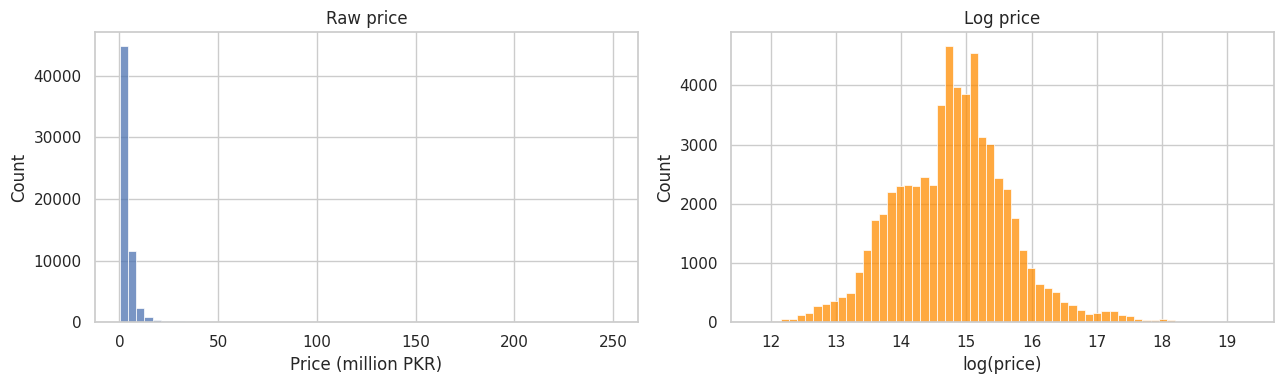

Skew raw: 9.65 | Skew log: 0.23


In [29]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df_clean["price"] / 1e6, bins=60, ax=ax[0])
ax[0].set(title="Raw price", xlabel="Price (million PKR)")
sns.histplot(df_clean["log_price"], bins=60, ax=ax[1], color="darkorange")
ax[1].set(title="Log price", xlabel="log(price)")
plt.tight_layout(); plt.savefig("images/01_price_distribution.png", dpi=150); plt.show()

print("Skew raw:", round(df_clean["price"].skew(), 2),
      "| Skew log:", round(df_clean["log_price"].skew(), 2))

Insight 2: price falls with age

Takeaway: Cars lose value fastest in the first few years, from roughly 8.5M at age 0 to under 4M by age 3, then decline slowly.

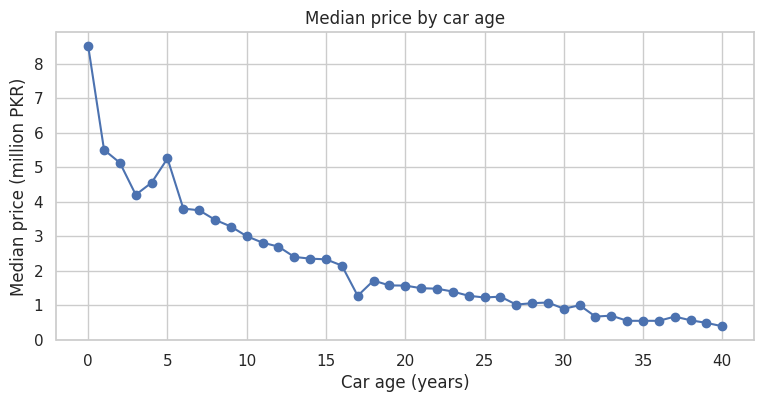

In [30]:
age = df_clean[df_clean["car_age"] <= 40].groupby("car_age")["price"].median() / 1e6
plt.figure(figsize=(9, 4))
age.plot(marker="o")
plt.title("Median price by car age"); plt.xlabel("Car age (years)"); plt.ylabel("Median price (million PKR)")
plt.savefig("images/02_price_by_age.png", dpi=150); plt.show()

Insight 3: brand matters
Takeaway: Median price varies about 6x between the cheapest and the most expensive makes, so brand is a strong predictor and a good basis for "brand tier" features.

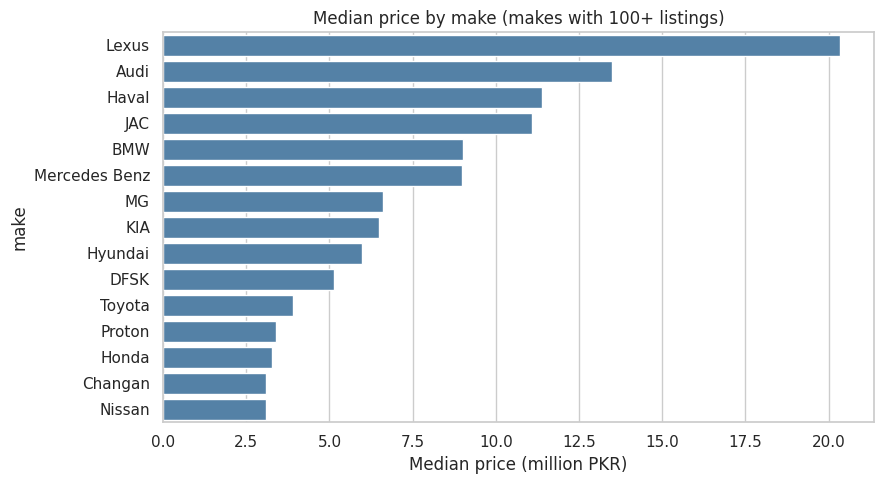

In [31]:
counts = df_clean["make"].value_counts()
big = counts[counts >= 100].index
top = (df_clean[df_clean["make"].isin(big)].groupby("make")["price"].median()
       .sort_values(ascending=False).head(15) / 1e6)
plt.figure(figsize=(9, 5))
sns.barplot(x=top.values, y=top.index, color="steelblue")
plt.title("Median price by make (makes with 100+ listings)"); plt.xlabel("Median price (million PKR)")
plt.tight_layout(); plt.savefig("images/03_price_by_make.png", dpi=150); plt.show()

Insight 4: mileage vs price

Takeaway: Mileage is only weakly related to price (-0.28), much less than car age (-0.64), because older cars carry a wide range of mileage values.

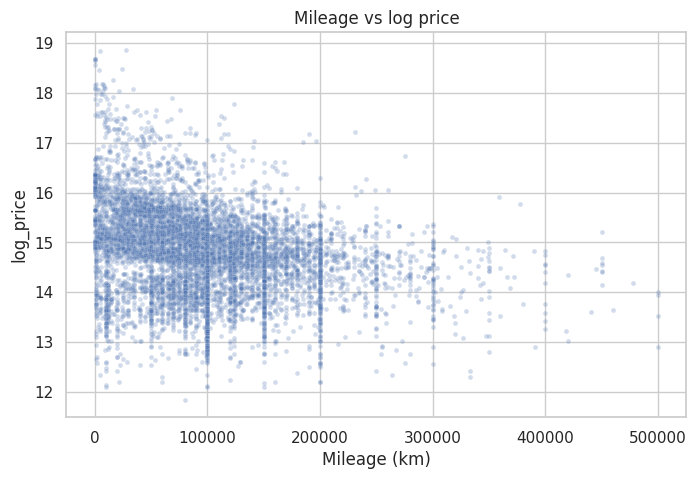

log_price     1.00
car_age      -0.64
mileage_km   -0.28
engine_cc     0.51
n_features    0.71
Name: log_price, dtype: float64


In [32]:
sample = df_clean.dropna(subset=["mileage_km"]).sample(8000, random_state=1)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x="mileage_km", y="log_price", alpha=0.25, s=12)
plt.title("Mileage vs log price"); plt.xlabel("Mileage (km)")
plt.savefig("images/04_mileage_vs_price.png", dpi=150); plt.show()

print(df_clean[["log_price", "car_age", "mileage_km", "engine_cc", "n_features"]].corr()["log_price"].round(2))

In [33]:
q1, q3 = df_clean["log_price"].quantile([.25, .75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
out = (df_clean["log_price"] < low) | (df_clean["log_price"] > high)
print(f"IQR bounds in PKR: {np.expm1(low):,.0f} to {np.expm1(high):,.0f}")
print("Rows outside the bounds:", out.sum(), f"({out.mean():.1%})")

IQR bounds in PKR: 279,095 to 23,438,176
Rows outside the bounds: 1268 (2.1%)


In [34]:
!git add .
!git commit -m "EDA insights 1-4"
!git push

[main 4ab6879] EDA insights 1-4
 4 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 images/01_price_distribution.png
 create mode 100644 images/02_price_by_age.png
 create mode 100644 images/03_price_by_make.png
 create mode 100644 images/04_mileage_vs_price.png
Enumerating objects: 8, done.
Counting objects: 100% (8/8), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (7/7), 359.02 KiB | 14.36 MiB/s, done.
Total 7 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/ma5029blp-wq/pricesense.git
   9aeccff..4ab6879  main -> main


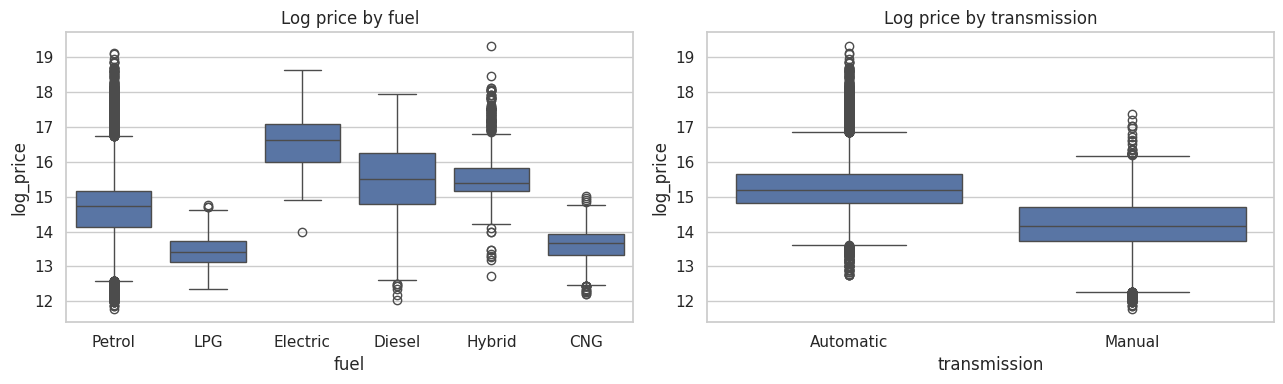

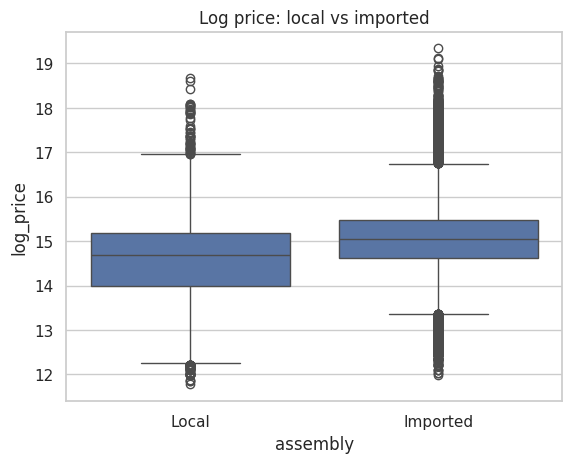

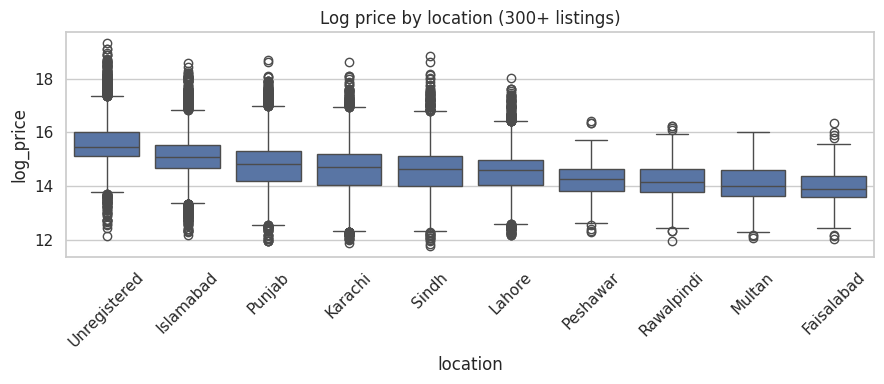

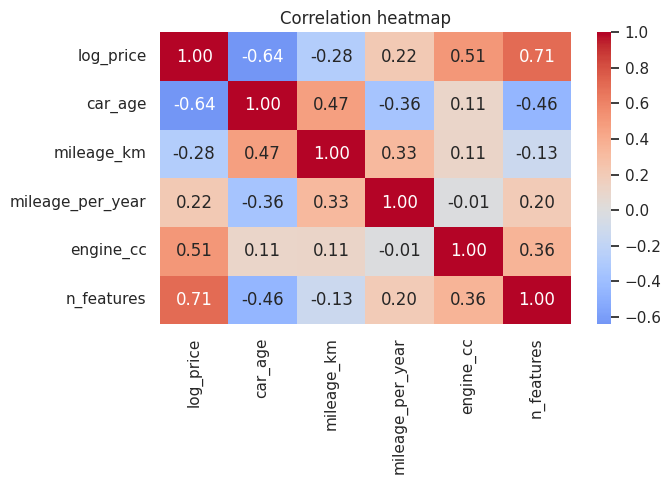

In [35]:
# Insight 5: price by fuel and transmission
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df_clean, x="fuel", y="log_price", ax=ax[0])
ax[0].set_title("Log price by fuel")
sns.boxplot(data=df_clean, x="transmission", y="log_price", ax=ax[1])
ax[1].set_title("Log price by transmission")
plt.tight_layout(); plt.savefig("images/05_fuel_transmission.png", dpi=150); plt.show()

# Insight 6: imported vs local
sns.boxplot(data=df_clean, x="assembly", y="log_price")
plt.title("Log price: local vs imported")
plt.savefig("images/06_assembly.png", dpi=150); plt.show()

# Insight 7: location and registration
loc = df_clean["location"].value_counts()
big_loc = loc[loc >= 300].index
order = (df_clean[df_clean["location"].isin(big_loc)].groupby("location")["price"].median()
         .sort_values(ascending=False).index)
plt.figure(figsize=(9, 4))
sns.boxplot(data=df_clean[df_clean["location"].isin(big_loc)], x="location", y="log_price", order=order)
plt.xticks(rotation=45); plt.title("Log price by location (300+ listings)")
plt.tight_layout(); plt.savefig("images/07_location.png", dpi=150); plt.show()

# Insight 8: correlation heatmap with mileage per year
df_clean["mileage_per_year"] = df_clean["mileage_km"] / df_clean["car_age"].clip(lower=1)
num = ["log_price", "car_age", "mileage_km", "mileage_per_year", "engine_cc", "n_features"]
plt.figure(figsize=(7, 5))
sns.heatmap(df_clean[num].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.tight_layout(); plt.savefig("images/08_heatmap.png", dpi=150); plt.show()

**Insight 5: fuel and transmission**

Takeaway: Fuel type and transmission both separate prices clearly: Electric, Diesel and Hybrid cost the most, CNG and LPG the least, and Automatics sell for roughly e^1 ≈ 2.7x the price of Manuals.

**Insight 6: local vs imported**

Takeaway: Imported cars carry a modest premium over locally assembled ones, but the overlap shows that assembly alone is a weak predictor.

**Insight 7: location and registration**

Takeaway: Location shifts prices noticeably: Islamabad listings are priced above Punjab and Sindh cities, and the "Unregistered" group is the most expensive.

**Insight 8: correlation heatmap**

Takeaway: n_features and car_age are the strongest numeric drivers of price, and mileage_per_year has a weak positive link with price, which is surprising.

In [36]:
!git add .
!git commit -m "EDA insights 5-8"
!git push

[main 4c82661] EDA insights 5-8
 4 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 images/05_fuel_transmission.png
 create mode 100644 images/06_assembly.png
 create mode 100644 images/07_location.png
 create mode 100644 images/08_heatmap.png
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (7/7), 230.49 KiB | 10.48 MiB/s, done.
Total 7 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/ma5029blp-wq/pricesense.git
   4ab6879..4c82661  main -> main
